In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from scipy.linalg import solve, block_diag
from numpy import block
import pandas as pd

## Problem 1: linear data fitting

In this problem, you are trying to find an approximation to the periodic function $f(t)=e^{\sin(t-1)}$ over one period, $0\leq t\leq 2\pi$.

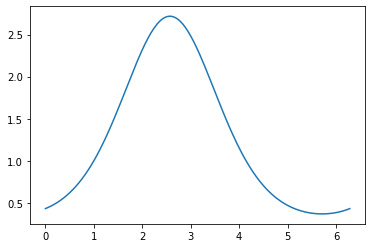

In [2]:
m = 200
t = np.linspace(0,2*np.pi,m)
y = np.exp(np.sin(t-1))
plt.plot(t,y)

**Part 1 (polynomial approximation):** Find the coefficients of the least squares fit

$$
f(t) \approx c_1 + c_2t + \cdots + c_7 t^7
$$

In [3]:
# fit a degree-d polynomial
d =6
A = np.ones((m,d+1))
for i in range(d+1):
     A[:,i] = t**i

# solve least squares problem
coeffs_a = lstsq(A,y)[0]
coeffs_a

array([ 0.58813557, -0.85735887,  1.60715159, -0.19406438, -0.16840821,
        0.04600638, -0.00322374])

**Part 2 (trigonometric polynomial approximation):** Find the coefficients of the least squares fit

$$
f(t) \approx d_1 + d_2\cos(t) + d_3 \sin(t) + d_4\cos(2t) + d_5\sin(2t).
$$

In [4]:
# fit a trigonometric degree-d polynomial
dim =4
B = np.ones((m,dim+1))
B[:,1]=np.cos(t)
B[:,2]=np.sin(t)
B[:,3]=np.cos(2*t)
B[:,4]=np.sin(2*t)

# solve least squares problem
coeffs_b = lstsq(B,y)[0]
coeffs_b

array([ 1.26608136, -0.95109901,  0.61071353,  0.11301289, -0.24687001])

**Part 3:** Plot the original function $f(t)$ and the two approximations from parts 1 and 2 together (on a well-labeled graph).

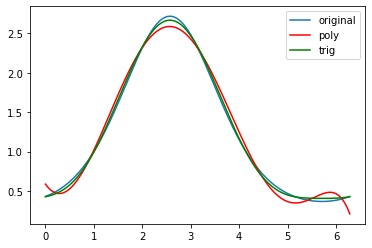

In [5]:
# plot data + fitted polynomial
plt.plot(t,y,label='original')

A_plot = np.ones((m,d+1))
for i in range(d+1):
    A_plot[:,i] = t**i
a_plot = A_plot.dot(coeffs_a)
plt.plot(t,a_plot, color='red',label='poly')
b_plot = B.dot(coeffs_b)
plt.plot(t,b_plot,color='green',label='trig')
plt.legend()

## Problem 2: constrained data fitting

Consider the following data points

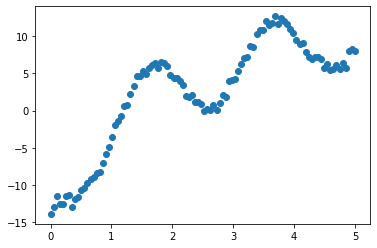

In [6]:
m = 100
t = np.linspace(0,5,m)
y = 5+.1*t-4*np.sin(np.pi*t)+2*np.cos(np.pi*t)-20*np.exp(-t)+0.1*t**(2.5)+0.5*np.random.randn(m)
plt.scatter(t,y)

Find the coefficients of the least squares fit

$$
f(t) = a_1 + a_2t+a_3\sin(\pi t)+ a_4\cos(\pi t)+a_5e^{-t} + a_6t^{2.5}
$$

such that $f(5)=11$ and $f^\prime(0)=0$.
Then plot the data points and the fitted function.

In [7]:
# parameters
a = 2.5
deg = 5
#xsort = np.sort(x)
t1 = t[t<=a]
m1 = len(t1)
t2 = t[t>a]
m2 = len(t2)

In [8]:
m1,m2

(50, 50)

In [9]:
# matrix A
A1 = np.ones((m1,deg+1))
A2 = np.ones((m2,deg+1))
for i in range(deg+1):
    A1[:,i] = t1**i
    A2[:,i] = t2**i
A = block_diag(A1,A2)

# vector b
b = np.concatenate((y[t<=a],y[t>a]))

In [10]:
# matrix C
C = np.zeros((2,2*(deg+1)))
C[0,0:deg+1] = [a**i for i in range(deg+1)]
C[0,deg+1:] = [-a**i for i in range(deg+1)]
C[1,1:deg+1] = [i*a**(i-1) for i in range(1,deg+1)]
C[1,deg+2:] = [-i*a**(i-1) for i in range(1,deg+1)]

# vector d
d = np.array([0,0])

In [11]:
Matrix = block([[A.T.dot(A),C.T],[C,np.zeros((2,2))]])
vector = np.concatenate((A.T.dot(b),d))

In [12]:
solution = solve(Matrix,vector)

In [13]:
coeff1 = solution[0:deg+1]
coeff2 = solution[deg+1:2*(deg+1)]
solution.shape

(14,)

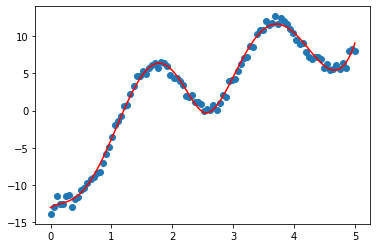

In [14]:
plt.scatter(t,y)

# p(x)
m_plot = 100
t1_plot = np.linspace(np.min(t),a,m_plot)
t2_plot = np.linspace(a,np.max(t),m_plot)
A1_plot = np.ones((m_plot,deg+1))
A2_plot = np.ones((m_plot,deg+1))
for i in range(deg+1):
    A1_plot[:,i] = t1_plot**i
    A2_plot[:,i] = t2_plot**i
y1_plot = A1_plot.dot(coeff1)
y2_plot = A2_plot.dot(coeff2)
plt.plot(t2_plot,y2_plot,color='red')
plt.plot(t1_plot,y1_plot,color='red')

## Problem 3: fitting an exponential to data

**Introduction**: The most familiar and common case of a polynomial least squares fit is the straight line $y=f(t)=at+b$.
Certain other fit functions can be transformed into this situation.
For example, suppose you want to fit data using $y = c_1e^{c_2t}$.
Then, 

$$
\log(y) = \log(c_1) + c_2t
$$

Thus, the variable $\log(y)$ can be fitted linearly in terms of the variable $t$.

Similarly, the power-law $y=c_1 t^{c_2}$ is equivalent to

$$
\log(y) = \log(c_1) + c_2 \log(t)
$$

Thus, the variable  $\log(𝑦)$  can be fitted linearly in terms of the variable  $\log(t)$.

In python, these two cases (exponential fit and power law) are easily discerned by using `plt.semilogy` or `plt.loglog` plots respectively

**Part 0:** Consider the following data points

Text(0.5, 1.0, 'plot with log scaling on both the x and y axis')

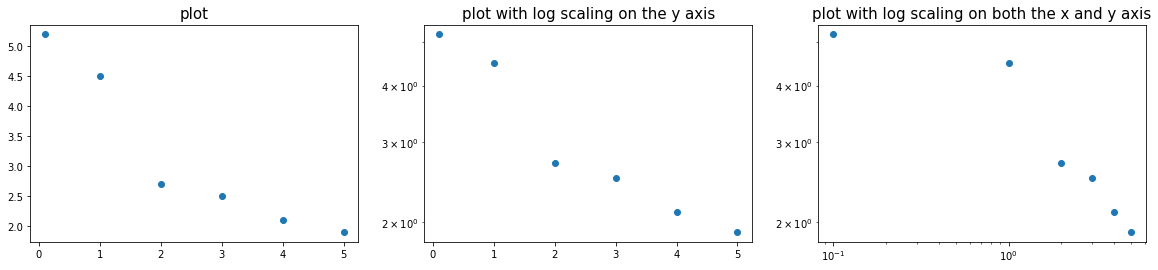

In [15]:
X = np.array([
    [0.1,1,2,3,4,5],
    [5.2,4.5,2.7,2.5,2.1,1.9]
])

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(X[0],X[1],'o')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(X[0],X[1],'o')
plt.title('plot with log scaling on the y axis', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(X[0],X[1],'o')
plt.title('plot with log scaling on both the x and y axis', fontsize=15)

**Part 1:** Fit a line to the data points. 

In [16]:
n = 6
A = np.ones((n,2))
A[:,1] = X[0]
coeffs = lstsq(A,X[1])[0]

[ 4.88786869 -0.69054385]


Text(0.5, 1.0, 'plot with log scaling on both the x and y axis')

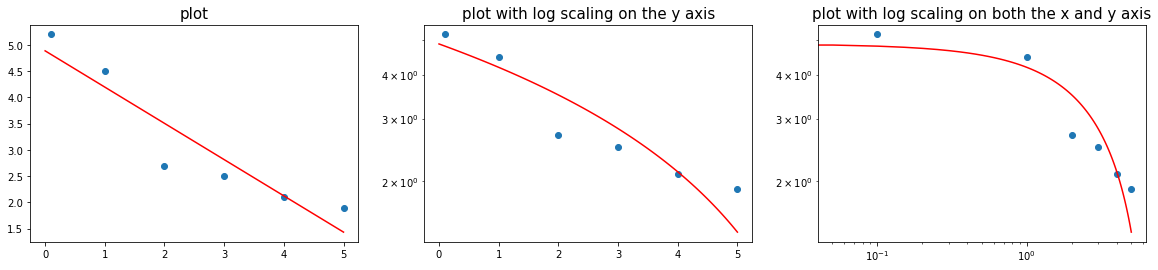

In [17]:
n_plot = 100
x_plot = np.linspace(0,5,n_plot)
A_plot = np.ones((n_plot,2))
A_plot[:,1] = x_plot
y_plot1 = A_plot.dot(coeffs)
print(coeffs)

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(X[0],X[1],'o')
plt.plot(x_plot,y_plot1,color='red')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(X[0],X[1],'o')
plt.plot(x_plot,y_plot1,color='red')
plt.title('plot with log scaling on the y axis', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(X[0],X[1],'o')
plt.plot(x_plot,y_plot1,color='red')
plt.title('plot with log scaling on both the x and y axis', fontsize=15)

**Part 2:** Fit an exponential function $f(t)=c_1e^{c_2t}$ to the data points.

[ 1.61313176 -0.21408747]


Text(0.5, 1.0, 'plot with log scaling on both the x and y axis')

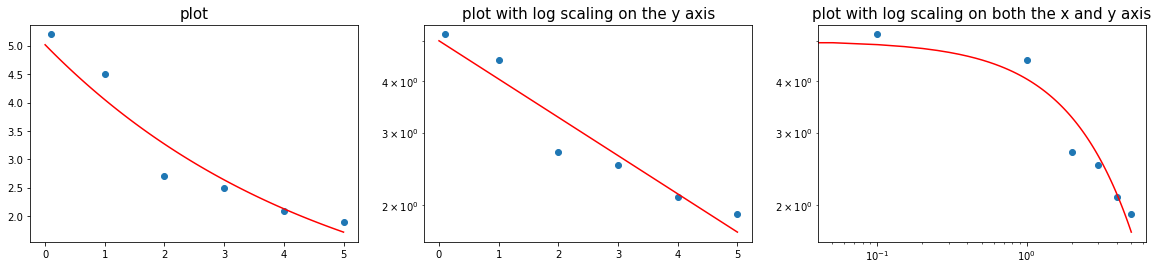

In [18]:
n = 6
A = np.ones((n,2))
A[:,1] = X[0]
coeffs = lstsq(A,np.log(X[1]))[0]
print(coeffs)

# solve least squares problem
n_plot = 100
x_plot = np.linspace(0,5,n_plot)
A_plot = np.ones((n_plot,2))
A_plot[:,1] = x_plot
y_plot2 = A_plot.dot(coeffs)

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(X[0],X[1],'o')
plt.plot(x_plot,np.exp(y_plot2),color='red')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(X[0],X[1],'o')
plt.plot(x_plot,np.exp(y_plot2),color='red')
plt.title('plot with log scaling on the y axis', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(X[0],X[1],'o')
plt.plot(x_plot,np.exp(y_plot2),color='red')
plt.title('plot with log scaling on both the x and y axis', fontsize=15)

**Part 3:** Fit a power-law function $f(t)=c_1 t^{c_2}$ to the data points. 

[ 1.18148429 -0.25869623]


Text(0.5, 1.0, 'plot with log scaling on both the x and y axis')

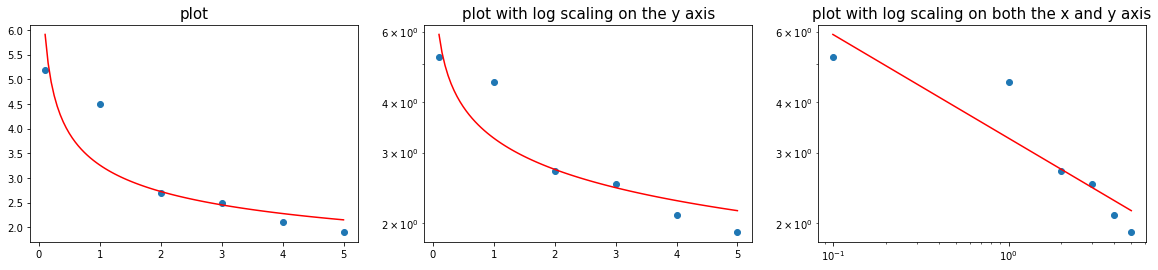

In [19]:
n = 6
A = np.ones((n,2))
A[:,1] = np.log(X[0])
coeffs = lstsq(A,np.log(X[1]))[0]
print(coeffs)

# solve least squares problem
n_plot = 100
x_plot = np.linspace(0.1,5,n_plot)
A_plot = np.ones((n_plot,2))
A_plot[:,1] = np.log(x_plot)
y_plot3 = A_plot.dot(coeffs)

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(X[0],X[1],'o')
plt.plot(x_plot,np.exp(y_plot3),color='red')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(X[0],X[1],'o')
plt.plot(x_plot,np.exp(y_plot3),color='red')
plt.title('plot with log scaling on the y axis', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(X[0],X[1],'o')
plt.plot(x_plot,np.exp(y_plot3),color='red')
plt.title('plot with log scaling on both the x and y axis', fontsize=15)

**Part 4:** Plot the data points, and the three fitted functions from parts 1, 2 and 3 (on a well-labeled graph)

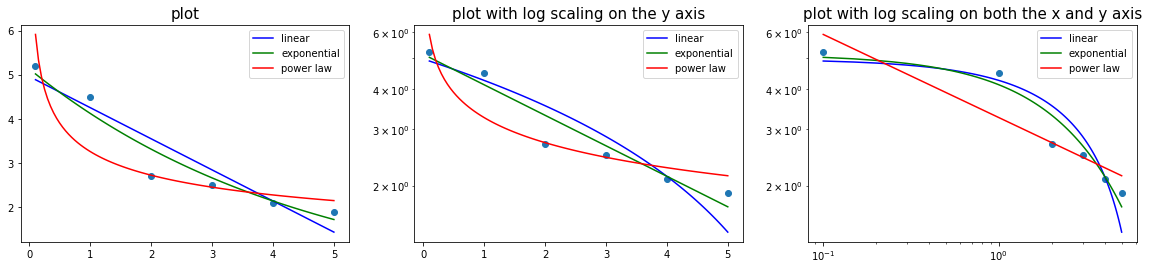

In [20]:
plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(X[0],X[1],'o')
plt.plot(x_plot,y_plot1,color='blue',label='linear')
plt.plot(x_plot,np.exp(y_plot2),color='green',label='exponential')
plt.plot(x_plot,np.exp(y_plot3),color='red',label='power law')
plt.title('plot', fontsize=15)
plt.legend()
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(X[0],X[1],'o')
plt.plot(x_plot,y_plot1,color='blue',label='linear')
plt.plot(x_plot,np.exp(y_plot2),color='green',label='exponential')
plt.plot(x_plot,np.exp(y_plot3),color='red',label='power law')
plt.title('plot with log scaling on the y axis', fontsize=15)
plt.legend()
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(X[0],X[1],'o')
plt.plot(x_plot,y_plot1,color='blue',label='linear')
plt.plot(x_plot,np.exp(y_plot2),color='green',label='exponential')
plt.plot(x_plot,np.exp(y_plot3),color='red',label='power law')
plt.title('plot with log scaling on both the x and y axis', fontsize=15)
plt.legend()

## Problem 4: numerical approximations to $\pi$

A famous series for finding $\pi$ is

$$
\frac{\pi^2}{6} = 1 + \frac{1}{2^2} + \frac{1}{3^2} + \frac{1}{4^2} + \frac{1}{5^2} + \cdots
$$

Let us denote by $s_k$ the sum of the first $k$ terms of the series above, and let $p_k=\sqrt{6s_k}$.
Here is a fancy way to compute these sequences in a compact code (using list comprehensions and `numpy`'s `cumsum` function).

In [21]:
k_max = 100
s = np.cumsum([1/i**2 for i in range(1,k_max)]) # cumulative summation
p = np.sqrt(6*s)

Text(0.5, 1.0, 'sequence converging to $\\pi$')

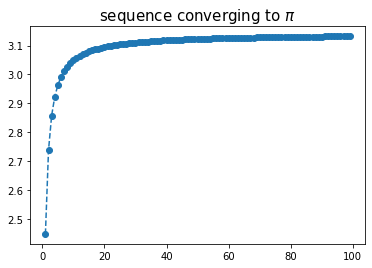

In [22]:
plt.plot(range(1,k_max), p,'o--')
plt.title('sequence converging to $\pi$',fontsize=15)

The graph suggests that $p_k\rightarrow \pi$ but doesn't give much information about the rate of convergence.

Let $e_k=|\pi-p_k|$ be the sequence of errors

Text(0.5, 1.0, 'loglog plot')

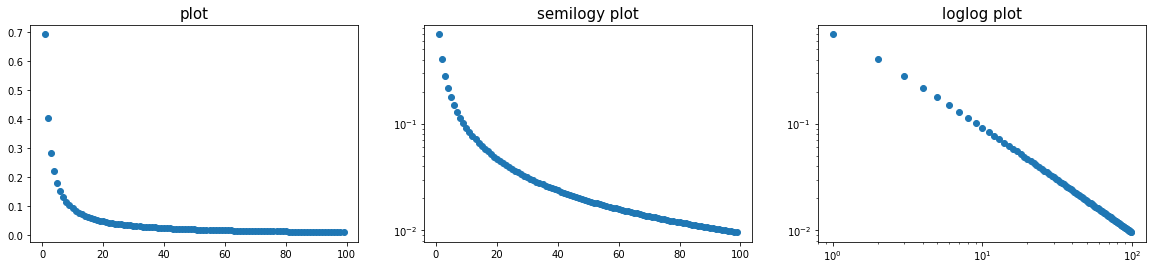

In [23]:
# sequence of errors
e = np.abs(np.pi - p)

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(range(1,k_max),e,'o')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(range(1,k_max),e,'o')
plt.title('semilogy plot', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(range(1,k_max),e,'o')
plt.title('loglog plot', fontsize=15)

The loglog plot suggests a power-law relationship $e_k = c_1k^{c_2}$

**Part 1:** Find the parameters $c_1$ and $c_2$.

The coefficients c1 and c2 [-0.18292818 -0.96720972]


Text(0.5, 1.0, 'loglog plot')

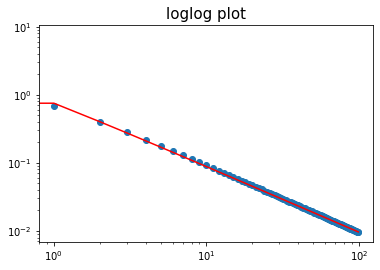

In [31]:
n = 99
A = np.ones((n,2))
A[:,1] = np.log(range(1,k_max))
coeffs = lstsq(A,np.log(e))[0]
print("The coefficients c1 and c2",coeffs)

# solve least squares problem
n_plot = 100
x_plot = np.linspace(0.1,k_max,n_plot)
A_plot = np.ones((n_plot,2))
A_plot[:,1] = np.log(x_plot)
y_plot4 = A_plot.dot(coeffs)
plt.loglog(range(1,k_max),e,'o')
plt.plot(range(0,k_max),np.exp(y_plot4),color='red')
plt.title('loglog plot', fontsize=15)

**Part 2:** Another series for finding $\pi$ is

$$
\frac{\pi}{2} = 1 + \frac{1}{3} + \frac{1 \cdot 2}{3 \cdot 5} + \frac{1 \cdot 2 \cdot 3}{3 \cdot 5 \cdot 7} + \frac{1 \cdot 2 \cdot 3 \cdot 4}{3 \cdot 5 \cdot 7 \cdot 9} + \cdots
$$

Define $s_k$ to be the sum of the first $k$ terms, and let $e_k=|\pi-2s_k|$.
Do a numerical experiment to determine which is a better fit, $e_k=c_1 c_2^k$ or $e_k=c_1 k^{c_2}$.
Then determine the parameters $c_1,c_2$ in that fit.

In [39]:
from scipy.special import factorial
k_max = 100
s = np.cumsum([factorial(i)/factorial(2*i+1) for i in range(1,k_max)]) # cumulative summation
#p = np.sqrt(6*s)

Text(0.5, 1.0, 'sequence converging to $\\pi$')

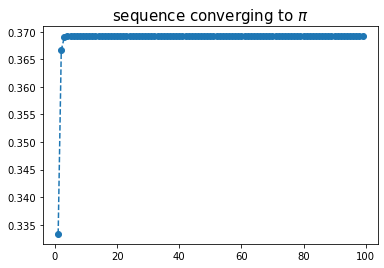

In [40]:
plt.plot(range(1,k_max), 2*s,'o--')
plt.title('sequence converging to $\pi$',fontsize=15)

Text(0.5, 1.0, 'loglog plot')

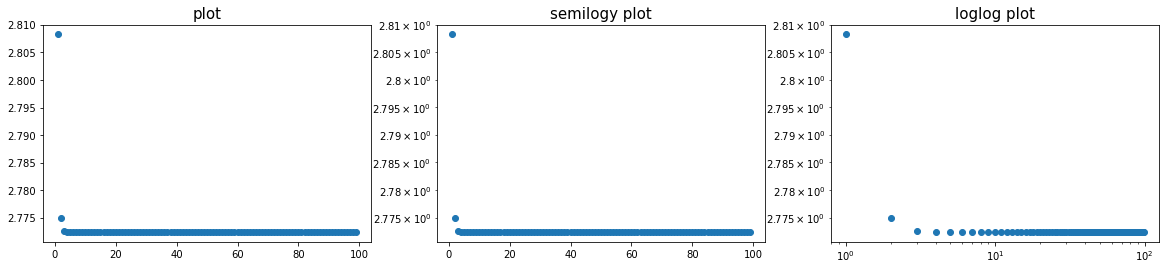

In [41]:
# sequence of errors
e = np.abs(np.pi - 2*s)

plt.figure(figsize=(20,4))
# plot
plt.subplot(1,3,1)
plt.plot(range(1,k_max),e,'o')
plt.title('plot', fontsize=15)
# plot with log scaling on the y axis
plt.subplot(1,3,2)
plt.semilogy(range(1,k_max),e,'o')
plt.title('semilogy plot', fontsize=15)
# plot with log scaling on both the x and y axis
plt.subplot(1,3,3)
plt.loglog(range(1,k_max),e,'o')
plt.title('loglog plot', fontsize=15)

## Problem 5: nonlinear data fitting

**Part 1:** Inhibited enzyme reactions often follow what are known as *Michaelis-Menten* kinetics, in which a reaction rate follows a law of the form

$$
v(t) = \frac{Vt}{K+t},
$$
where $t$ is the concentration of a substrate.

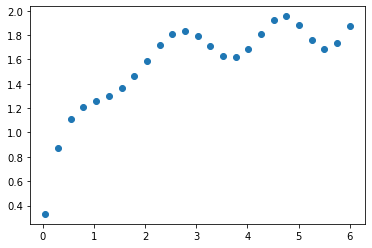

In [42]:
# generate some synthetic data with V=2 and K=1/2
m = 25
t = np.linspace(0.05,6,m)
y = 2*t/(0.5+t) + 0.15*np.cos(2*np.exp(t/16)*t)
plt.scatter(t,y)

Use nonlinear least squares to fit a function of the form $v(t) = \frac{Vt}{K+t}$ to the data. 
Then plot the data and the fitted function.

In [43]:
# function f(x)
def fun(x,y,t):
    return x[0]*t/(x[1]+t)-y

In [44]:
# Jacobian of f(x)
def Derf(t,y,x):
    return np.hstack((
                    x[0]*t/(x[1]+t).reshape(m,1),
                    (2*(x[0]/x[1])*(t-x[1])*x[0]*t/(x[1]+t)).reshape(m,1),
                    ))

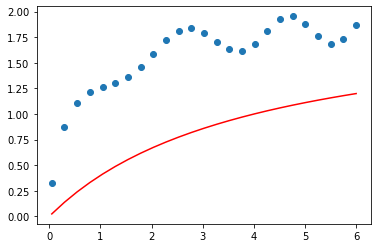

In [52]:
# starting point
x = np.array([2,4])

# starting fitted function
m_plot = 25
t_plot = np.linspace(np.min(t),np.max(t),m_plot)
y_plot = x[0]*t/(x[1]+t)
plt.scatter(t,y)
plt.plot(t_plot,y_plot,  color='red')

**Part 2:** A famous result suggests that in epidemics that kill only a small fraction of a susceptible population, the **death rate** as a function of time is well modeled by

$$
A\,\mathrm{sech}^2\,\left(B(t-C)\right),
$$

where $\mathrm{sech}$ is the hyperbolic secant.

You will use this model to fit the deaths per week from plague recorded in Mumbai in a period during 1906.

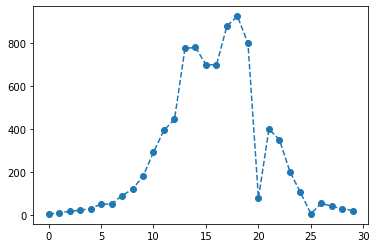

In [55]:
deaths = np.array([
    5,10,17,22,30,50,51,90,120,180,292,395,445,775,780,700,698,880,925,800,78,400,350,202,105,6,55,40,30,20
])
plt.plot(deaths,'o--')

Find the best least squares fit to the data. 
Make a plot of the fitted model and the data points.

## Problem 6: (linear) fitting of an ellipse

An ellipse in a plane can be described (implicitly) as the set of points $\begin{bmatrix} 
x \\ y 
\end{bmatrix}$ that satisfy

$$
f(x,y) = ax^2 + bxy + cy^2 + dx + ey = 1,
$$

where $a,b,c,d,e$ are the parameters that describe the ellipse.

Your goal is to fit an ellipse ro $m$ points $\begin{bmatrix} x_1 \\ y_1 \end{bmatrix}, \begin{bmatrix} x_2 \\ y_2 \end{bmatrix}, \ldots, \begin{bmatrix} x_m \\ y_m \end{bmatrix}$ by minimizing 

$$
\sum_{i=1}^m (f(x_i,y_i)-1)^2
$$

In [ ]:
# m=8 points in R2
X = np.array([
    [1, 2, 5, 7, 9, 6, 3, 8],
    [7, 6, 8, 7, 5, 7, 2, 4]
    ])
plt.scatter(X[0],X[1])

**Part 1:** Find the ellipse (i.e., find the parameters $a,b,c,d,e$) that best fits the $m=8$ given points.

**Part 2:** Plot the given points and the fitted ellipse.

Hint: to plot the ellipse, you'll need to use `plt.contour` function.
For example, the cell below plots the implicit curve $x^2+2y^2=4$

In [ ]:
# set x and y ranges and precision
x = np.arange(-3,3.5,0.01) 
y = np.arange(-2,2,0.01)
# create a grid
xx,yy=np.meshgrid(x,y)
# evaluate equation at grid points
zz = xx**2 + 2*yy**2
# contour plot
plt.contour(xx,yy,zz,levels=[4])

## Problem 7: (non linear) fitting of an ellipse

An ellipse in a plane can be described (explicitly) as the set
of points 

$$
\begin{bmatrix} 
x \\ y 
\end{bmatrix}  = f(t) =
\begin{bmatrix} 
c_1 + r \cos(\alpha + t) + \delta \cos(\alpha-t) \\
c_2 + r \sin(\alpha + t) + \delta \sin(\alpha-t) 
\end{bmatrix},
$$

where t ranges from 0 to $2\pi$.
The vector $\theta = (c_1, c_2, r, \delta, \alpha)$ contains five parameters, with geometrical meanings illustrated in the figure below.

In [ ]:
from IPython.display import Image
Image(filename="ellipse.png")

Your goal is to fit an ellipse by minimizing the sum of the squared distances of $m$ points $\begin{bmatrix} x_1 \\ y_1 \end{bmatrix}, \begin{bmatrix} x_2 \\ y_2 \end{bmatrix}, \ldots, \begin{bmatrix} x_m \\ y_m \end{bmatrix}$ to the
ellipse.


In [ ]:
# m=10 points in R2
X = np.array([
    [0.5,-.3,1,-.4,.2,.7,2.3,1.4,.0,2.4],
    [1.5,.6,1.8,.2,1.3,.1,.8,.5,.2,1.7]
])
plt.scatter(X[0],X[1])

**Part 1:** Minimize the sum of the squared distances of the data points to the ellipse 

$$
\sum_{i=1}^m \left\| \begin{bmatrix}x_i\\y_i\end{bmatrix} - f(t_i) \right\|_2^2
$$

over $t_1,t_2,\ldots,t_m$ and $c_1, c_2, r, \delta, \alpha$

**Part 2:** Plot the given points and the fitted ellipse.